In [48]:
import requests
import pandas as pd 
import numpy as np
import time
import calendar
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.preprocessing import RobustScaler,StandardScaler

In [49]:
api_key='b0b16ad6834c4ebea1b181e3afa92e21'
technical='time_series'
ticker='BTC/USD'
timezone='Asia/Calcutta'
interval='30min'

In [186]:
import time
import calendar
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
data=[]
for yr in range(2022,2026):
    for m in range(1,5):
        last_day=calendar.monthrange(yr,3*m)[1]
        start_date=f'{yr}-{(3*m-2):02d}-01T00:00:00'
        end_date=f'{yr}-{(3*m):02d}-{last_day}T23:30:00'
        api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
        while True:
            session=requests.Session()
            retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
            session.mount("https://",HTTPAdapter(max_retries=retries))
            fetch=session.get(api_url).json()
            if "values" in fetch:
                df=pd.DataFrame(fetch['values'])
                data.append(df)
                time.sleep(8)
                break
            elif "code" in fetch and fetch["code"]==429:
                print("Rate limit exceeded")
                time.sleep(15)
            else: 
                print("API Error:",fetch)
                fetch=None
                break
data=pd.concat(data,ignore_index=True)
data['color']=np.where(data['close']>data['open'],1,0)
data['open']=pd.to_numeric(data['open'])
data['close']=pd.to_numeric(data['close'])
data['abs_body']=abs(data['close']-data['open'])
data['body']=(data['close']-data['open'])
data['high']=pd.to_numeric(data['high'])
data['low']=pd.to_numeric(data['low'])

KeyboardInterrupt: 

In [ ]:
data['datetime']=pd.to_datetime(data['datetime'])
missing_times=pd.date_range("2022-01-01", "2025-12-31 23:30", freq="30T").difference(data['datetime'])
missing_times

In [ ]:
missing_times=pd.date_range(start="2022-02-19 19:30",end="2022-02-20 02:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[40417.019531, 40382.390620, 40495.820310, 40316.121090, 39856.980470, 40183.230470, 39976.660160, 40073.031250, 40052.289060, 39966.011719, 40165.449220, 40245.160160, 40225.781250, 40079.878910, 39969.539060],
    "high":[40497.32812, 40449.48047, 40739.82031, 40316.12109, 40377.17188, 40382.75, 40360.03125, 40164.83984, 40052.28906, 40194.71875, 40268.60156, 40353.83984, 40294.37891, 40178.96094, 40149.51172],
    "low":[40316.82031, 39673.44922, 40278.39844, 39693.89844, 39464.60938, 40004.41016, 39976.66016, 39963.35156, 39825.62109, 39943.26172, 40084.64062, 40094.92969, 40050.39062, 39960.55859, 39916.57031],
    "close":[40354.148440, 40437.609380, 40278.398440, 39790.531250, 40153.898440, 40004.410160, 40095.351560, 40032.710940, 39983.800780, 40193.539060, 40268.601560, 40218.441410, 40123.281250, 39966.988280, 40128.75],
    "abs_body":[62.871091,55.21876,217.42187,525.58984,296.91797,178.82031,118.6914,40.32031,68.48828,227.527341,103.15234,26.71875,102.5,112.89063,159.21094],
    "body":[-62.871091,55.21876,-217.42187,-525.58984,296.91797,-178.82031,118.6914,-40.32031,-68.48828,227.527341,103.15234,-26.71875,-102.5,-112.89063,159.21094]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-04-03 02:00",end="2022-04-03 02:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[46324.46094],
    "high":[46391.42188],
    "low":[46111.011719],
    "close":[46164.92969],
    "abs_body":[159.53125],
    "body":[-159.53125]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-05-06 00:30",end="2022-05-06 01:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[39601.14844,39844.64062],
    "high":[39972.55078,39903.19922],
    "low":[39545.058594,39671.89844],
    "close":[39840.53906,39816.12109],
    "abs_body":[239.39062,28.51953],
    "body":[239.39062,-28.51953]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-10-22 17:30",end="2022-10-22 18:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[18947.509770,18783.619140,18870.109380],
    "high":[18947.50977,18884.25,19004.060547],
    "low":[18679.75,18734.41016,18870.10938],
    "close":[18782.14062,18884.25,18962.26953],
    "abs_body":[165.369150,100.630860,92.16015],
    "body":[-165.369150,100.630860,92.160150]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-11-17 04:30",end="2022-11-17 05:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16861.900390,16844.580080,16880.15039],
    "high":[16877.58984,16882.83008,16911.92969],
    "low":[16824.43945,16820.90039,16782.50977],
    "close":[16839.30078,16880.15039,16782.50977],
    "abs_body":[22.599610,35.570310,97.640620],
    "body":[-22.599610,35.570310,-97.640620]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-11-18 05:00",end="2022-11-18 10:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16844.580080,16880.15039,16681.929690,16688.31055,16697.230470,16684.380860,16653.359380,16584.320310,16580.169920,16508.189450,16470.33008],
    "high":[16882.83008,16911.92969,16711.84961,16727.19922,16710.41992,16691.91016,16672.31055,16593.53906,16582.75977,16509.92969,16519.50977],
    "low":[16820.90039,16782.50977,16660.23047,16681.28906,16671.66992,16642.070312,16582.31055,16568.24023,16498.17969,16403.44922,16467.25],
    "close":[16880.15039,16782.50977,16688.230470,16697.349610,16680.490230,16655.009766,16582.310550,16583.050781,16502.509770,16472.599610,16489.439450],
    "abs_body":[35.570310,97.640620,6.30078,9.03906,16.74024,29.371094,71.04883,1.269529,77.660150,35.589840,19.109370],
    "body":[35.570310,-97.640620,6.300780,9.039060,-16.740240,-29.371094,-71.048830,-1.269529,-77.660150,-35.589840,19.109370]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-11-19 05:00",end="2022-11-19 19:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16844.58008,16880.15039,16681.92969,16688.31055,16697.23047,16684.38086,16653.35938,16584.32031,16580.16992,16508.18945,16470.33008,16825.42969,16810.34961,16791.14062,16744.73047,16778.31055,16767.76953,16727.86914,16711.51953,16715.65039,16727.16992,16730.38086,16781.96094,16750.039062,16736.25977,16737.16016,16754.5293,16759.91992,16777.41992,16742.2793],
    "high":[16882.83008,16911.92969,16711.84961,16727.19922,16710.41992,16691.91016,16672.31055,16593.53906,16582.75977,16509.92969,16519.50977,16825.42969,16815.41016,16806.4707,16788.050781,16785.25977,16770.11914,16731.35938,16721.9707,16740.089844,16745.68945,16789,16833.86914,16769.050781,16746.17969,16764.41992,16771.84961,16798.17969,16796.070312,16765.97070],
    "low":[16820.90039,16782.50977,16660.23047,16681.28906,16671.66992,16642.070312,16582.31055,16568.24023,16498.17969,16403.44922,16467.25,16806.82031,16772.98047,16744.21094,16743.75,16751.63086,16708.80078,16663.88086,16688.91016,16711.58984,16707.10938,16726.96094,16708.39062,16726.63086,16702.25977,16730.90039,16745.53906,16759.91992,16724.74023,16730.83008],
    "close":[16880.15039,16782.50977,16688.23047,16697.34961,16680.49023,16655.009766,16582.31055,16583.050781,16502.50977,16472.59961,16489.43945,16806.82031,16789.84961,16749.4707,16778.58984,16770.11914,16731.13086,16712.51953,16714.67969,16728.48047,16729.35938,16775.28906,16756.53906,16737.25,16737.83984,16753.91992,16764.2207,16777.070312,16744.66016,16759.94922],
    "abs_body":[35.57031,97.64062,6.30078,9.03906,16.74024,29.371094,71.04883,1.269529,77.66015,35.58984,19.10937,18.609380,20.5,41.66992,33.85937,8.19141,36.63867,15.34961,3.16016,12.83008,2.18946,44.9082,25.42188,12.789062,1.58007,16.75976,9.6914,17.150392,32.75976,17.66992],
    "body":[35.57031,-97.64062,6.30078,9.03906,-16.74024,-29.371094,-71.04883,-1.269529,-77.66015,-35.58984,19.10937,-18.609380,-20.5,-41.66992,33.85937,-8.19141,-36.63867,-15.34961,3.16016,12.83008,2.18946,44.9082,-25.42188,-12.789062,1.58007,16.75976,9.6914,17.150392,-32.75976,17.66992]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-11-20 14:30",end="2022-11-20 15:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16715.65039,16727.16992],
    "high":[16740.089844,16745.68945],
    "low":[16711.58984,16707.10938],
    "close":[16728.48047,16729.35938],
    "abs_body":[12.83008,2.18946],
    "body":[12.83008,2.18946]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-11-20 16:00",end="2022-11-20 16:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16730.38086],
    "high":[16789],
    "low":[16726.96094],
    "close":[16775.28906],
    "abs_body":[44.9082],
    "body":[44.9082]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2022-12-03 13:00",end="2022-12-03 16:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[16932.40039,16958.76953,16948.029297,16967.91016,16965.92969,16967.32031,16954.35938,16967.060547],
    "high":[16970.65039,16965.75977,16972.85938,16978.36914,16988.4707,16977.070312,16968.7207,16995.019531],
    "low":[16932.40039,16941.59961,16948.029297,16960.82031,16964.58984,16952.78906,16951.17969,16959.36914],
    "close":[16965.30078,16947.4707,16966.25977,16966.46094,16966.029297,16954.82031,16966.88086,16974.080078],
    "abs_body":[32.90039,11.29883,18.230473,1.44922,0.099607,12.5,12.52148,7.019531],
    "body":[32.90039,-11.29883,-18.230473,-1.44922,0.099607,-12.5,12.52148,7.019531]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2023-02-22 21:30",end="2023-02-23 11:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[24563.85938,24381.33984,24409.80078,24401.59961,24641.91016,24629.23047,24689.48047,24640.019531,24607.7207,24449.66992,24459.94922,24241.070312,24190.16992,24295.82031,24389,24361.81055,24452.98047,24412.73047,24403.23047,24360.14062,24203.83984,24036.24023,24172.31055,24229.11914,24201.96094,24163.82031,24158.83984,24026.33008,24102.78906],
    "high":[24587.75977,24444.42969,24444.65039,24652.85938,24746.90039,24732.019531,24693.90039,24686.53906,24642.88086,24525.67969,24536.65039,24332.26953,24316.30078,24428.84961,24404.33984,24451.90039,24474.51953,24425.5293,24432.75,24392.070312,24203.83984,24195.30078,24270.40039,24247.11914,24222.73047,24170.32031,24168.15039,24113.029297,24128.25977],
    "low":[24321.32031,24301.5293,24380.76953,24401.59961,24589.96094,24569.58008,24564.4707,24558.17969,24450.56055,24434.57031,24159.85938,24173.41016,24174.28906,24280.82031,24341.019531,24351.32031,24411.49023,24276.41016,24356.019531,24156.5,23969.66016,23873.0097656,24133.11914,24155.86914,24160.029297,24031.099609,24007.91992,24013.31055,24028.17969],
    "close":[24377.19922,24403.060547,24412.69922,24652.85938,24631.66016,24693.90039,24636.63086,24595.96094,24450.88086,24464.41016,24257.78906,24175.57031,24295.33984,24384.94922,24356.9707,24451.90039,24411.83984,24402.7793,24365.51953,24195.76953,24036.60938,24169.50977,24238.68945,24200.099609,24162.17969,24161.21094,24032.81055,24107.34961,24044.48047],
    "abs_body":[186.66016,21.720707,2.89844,251.25977,10.25,64.66992,52.84961,44.058591,156.83984,14.74024,202.16016,65.500002,105.16992,89.12891,32.0293,90.08984,41.14063,9.95117,37.71094,164.37109,167.23046,133.26954,66.3789,29.019531,39.78125,2.60937,126.02929,81.01953,58.30859],
    "body":[-186.66016,21.720707,2.89844,251.25977,-10.25,64.66992,-52.84961,-44.058591,-156.83984,14.74024,-202.16016,-65.500002,105.16992,89.12891,-32.0293,90.08984,-41.14063,-9.95117,-37.71094,-164.37109,-167.23046,133.26954,66.3789,-29.019531,-39.78125,-2.60937,-126.02929,81.01953,-58.30859]   
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2023-03-04 23:00",end="2023-03-05 01:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[22422.019531,22420.60938,22386.86914,22314.14062,22306.85938,22354.26953],
    "high":[22448.36914,22422.050781,22394.24023,22355.99023,22389.84961,22377.71094],
    "low":[22395.92969,22375.25,22263.57031,22294.13086,22301.080078,22333.2207],
    "close":[22417.42969,22394.24023,22316.21094,22311.89062,22356.48047,22355.060547],
    "abs_body":[4.589841,26.36915,70.6582,2.25,49.62109,0.791017],
    "body":[-4.589841,-26.36915,-70.6582,-2.25,49.62109,0.791017]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2023-07-20 00:00",end="2023-07-20 03:30",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[29929.14,29909.63,29775.01,29720.64,29728.11,29783.77,29830.69,29807.85],
    "high":[29932.4,29946.23,29817.33,29794.65,29818.44,29841.05,29831.53,29823.14],
    "low":[29859.69,29771.55,29685.27,29704.95,29690.39,29756.01,29778.89,29768.22],
    "close":[29910.96,29775,29722.14,29728.11,29783.61,29830.7,29807.88,29790.82],
    "abs_body":[18.18,134.63,52.87,7.47,55.5,46.93,22.81,17.03],
    "body":[-18.18,-134.63,-52.87,7.47,55.5,46.93,-22.81,-17.03]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2024-10-26 22:00",end="2024-10-26 22:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[67579.54],
    "high":[67864.16],
    "low":[67512.9],
    "close":[67633.74],
    "abs_body":[54.2],
    "body":[54.2]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
missing_times=pd.date_range(start="2025-10-25 21:00",end="2025-10-26 02:00",freq="30min")
missing_df=pd.DataFrame({
    "datetime":missing_times,
    "open":[110608.48,110070.08,110370.87,110282.04,110516.01,110231.46,110528.01,110621.56,110948.65,110624.01,110754],
    "high":[110636.73,110411.24,110378.96,110600,110519.16,110658.51,110654.51,110980.7,110955.64,110817.37,111040.55],
    "low":[109910.01,109804.93,109930,110195.8,110231.47,110165.84,110422,110617.05,110506.46,110485.4,110676.22],
    "close":[110070.09,110374.01,110286.93,110516.01,110233.73,110524.36,110621.56,110948.65,110624.14,110753.99,110920.22],
    "abs_body":[538.39,303.93,83.94,233.97,282.28,292.9,93.55,327.09,324.51,129.98,166.22],
    "body":[-538.39,303.93,-83.94,233.97,-282.28,292.9,93.55,327.09,-324.51,129.98,166.22]
})
data=pd.concat([data,missing_df],ignore_index=True)

In [ ]:
data['datetime']=pd.to_datetime(data['datetime'])
missing_times=pd.date_range("2022-01-01", "2025-12-31 23:30", freq="30T").difference(data['datetime'])
missing_times

In [ ]:
data['datetime']=pd.to_datetime(data['datetime'])
data=data.sort_values("datetime").reset_index(drop=True)
data

In [ ]:
data=pd.read_csv('BTC_22-25.csv')
data

In [ ]:
df=pd.read_csv('binance_22-25.csv')
df

In [ ]:
df_volume=[]
df_takervolume=[]
df_opentime=[]
df_trades=[]
interval='30m'
for yr in range(2022,2026):
    for m in range(1,13): 
        start_date=f'{yr}-{(m):02d}-01'
        end_date=f'{yr}-{(m):02d}-16'
        start_ms=int(time.mktime(time.strptime(start_date,"%Y-%m-%d")))*1000
        end_ms=int(time.mktime(time.strptime(end_date,"%Y-%m-%d")))*1000
        api_url=f"https://api1.binance.com/api/v3/klines?symbol=BTCUSDT&interval={interval}&startTime={start_ms}&endTime={end_ms}&limit=1000"
        while True:
            session=requests.Session()
            retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
            session.mount("https://",HTTPAdapter(max_retries=retries))
            fetch=session.get(api_url).json()
            if fetch:
                open_time=[value[0] for value in fetch]
                volume=[float(value[7]) for value in fetch]
                taker_volume=[float(value[10]) for value in fetch]
                trades=[float(value[8]) for value in fetch]
                df_volume.extend(volume)
                df_opentime.extend(open_time) 
                df_takervolume.extend(taker_volume)
                df_trades.extend(trades)
                time.sleep(4)
                break
            else: 
                print("API Error:",fetch)
                fetch=None
                break
        last_day=calendar.monthrange(yr,m)[1]
        start_date=f'{yr}-{(m):02d}-16'
        end_date=f'{yr}-{(m):02d}-{(last_day)}'
        start_ms=int(time.mktime(time.strptime(start_date,"%Y-%m-%d")))*1000
        end_ms=int(time.mktime(time.strptime(end_date,"%Y-%m-%d")))*1000
        api_url=f"https://api1.binance.com/api/v3/klines?symbol=BTCUSDT&interval={interval}&startTime={start_ms}&endTime={end_ms}&limit=1000"
        while True:
            session=requests.Session()
            retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
            session.mount("https://",HTTPAdapter(max_retries=retries))
            fetch=session.get(api_url).json()
            if fetch:
                open_time=[value[0] for value in fetch]
                volume=[float(value[7]) for value in fetch]
                taker_volume=[float(value[10]) for value in fetch]
                trades=[float(value[8]) for value in fetch]
                df_volume.extend(volume)
                df_opentime.extend(open_time) 
                df_takervolume.extend(taker_volume)
                df_trades.extend(trades)
                time.sleep(4)
                break
            else: 
                print("API Error:",fetch)
                fetch=None
                break
df=pd.DataFrame({
    'open_time':pd.to_datetime(df_opentime,unit='ms'),
    'volume':df_volume,
    'taker_volume':df_takervolume,
    'no_of_trades':df_trades
}).dropna()
df

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,Bidirectional,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
model=Sequential([
    LSTM(64,return_sequences=True,input_shape=(32,11)),
    Dropout(0.3),
    LSTM(32,return_sequences=False),
    Dropout(0.3),
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),   
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    # Dense(16,activation='relu'),
    # BatchNormalization(),
    # Dropout(0.2),
    Dense(1,activation='sigmoid')
])
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

c:\Users\#samay\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 32, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,665 (131.50 KB)

 Trainable params: 33,569 (131.13 KB)

 Non-trainable params: 96 (384.00 B)

In [51]:
data=pd.read_csv('BTC_22-25.csv')
df=pd.read_csv('binance_22-25.csv')

In [52]:
data['datetime']=pd.to_datetime(data['datetime'],format='%d-%m-%Y %H:%M')
data=data.sort_values('datetime').reset_index(drop=True)

In [53]:
data['datetime']=data['datetime'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata')

In [54]:
df['open_time']=pd.to_datetime(df['open_time'])
df=df.sort_values('open_time').reset_index(drop=True)
df['open_time']=df['open_time'].dt.tz_convert('Asia/Kolkata')

In [55]:
merged_data=pd.merge_asof(data,df,left_on='datetime',right_on='open_time',direction='nearest',tolerance=pd.Timedelta('30min'))
merged_data

,datetime,open,high,low,close,color,abs_body,body,upper_wick,lower_wick,open_time,volume,taker_volume,no_of_trades
0,2022-01-01 05:30:00+05:30,46894.30078,46951.76953,46557.17969,46640.53125,0,253.769530,-253.769530,57.468750,83.35156,2022-01-01 05:30:00+05:30,3.275119e+07,1.800036e+07,19674.0
1,2022-01-01 06:00:00+05:30,46656.26172,46656.26172,46075.00000,46080.87109,0,575.390630,-575.390630,0.000000,5.87109,2022-01-01 06:00:00+05:30,3.712879e+07,1.946179e+07,18934.0
2,2022-01-01 06:30:00+05:30,46064.07031,46318.87109,45656.55078,45693.14844,0,370.921872,-370.921872,254.800778,36.59766,2022-01-01 06:30:00+05:30,2.754998e+07,1.554390e+07,18930.0
3,2022-01-01 07:00:00+05:30,45671.73047,46195.80859,45655.42969,46037.41016,1,365.679690,365.679690,158.398430,16.30078,2022-01-01 07:00:00+05:30,1.657717e+07,7.419374e+06,12942.0
4,2022-01-01 07:30:00+05:30,46042.01953,46115.21094,45823.94922,45881.53906,0,160.480471,-160.480471,73.191409,57.58984,2022-01-01 07:30:00+05:30,1.281610e+07,5.467496e+06,13394.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70123,2026-01-01 03:00:00+05:30,87830.03000,87932.17000,87558.00000,87792.55000,0,37.480000,-37.480000,102.140000,234.55000,NaT,NaN,NaN,NaN
70124,2026-01-01 03:30:00+05:30,87797.91000,87813.02000,87259.01000,87531.06000,0,266.850000,-266.850000,15.110000,272.05000,NaT,NaN,NaN,NaN
70125,2026-01-01 04:00:00+05:30,87531.06000,87637.99000,87356.29000,87496.24000,0,34.820000,-34.820000,106.930000,139.95000,NaT,NaN,NaN,NaN
70126,2026-01-01 04:30:00+05:30,87496.25000,87550.34000,87400.76000,87487.96000,0,8.290000,-8.290000,54.090000,87.20000,NaT,NaN,NaN,NaN


In [56]:
data=merged_data

In [57]:
scaler=RobustScaler()

In [61]:
future_return=(data['close'].shift(-8)-data['close'])/data['close']
data['label']=np.where(future_return>0.00001,1,np.where(future_return<-0.00001,0,np.nan))   
# data['upper_wick']=np.where(data['color']==1,data['high']-data['close'],data['high']-data['open'])
# data['lower_wick']=np.where(data['color']==1,data['open']-data['low'],data['close']-data['low'])
# data['body_to_range']=data['body']/(data['high']-data['low']+1e-10)
data['upper_wick_ratio']=data['upper_wick']/(data['high']-data['low']+1e-10)
data['lower_wick_ratio']=data['lower_wick']/(data['high']-data['low']+1e-10)
data['price_change']=data['close'].pct_change()
data['price_change_2']=data['close'].pct_change(2)
data['price_change_4']=data['close'].pct_change(4)
data['price_change_8']=data['close'].pct_change(8)
# data['price_change_12']=data['close'].pct_change(12)
data['price_change_16']=data['close'].pct_change(16)
# data['price_change_20']=data['close'].pct_change(20)
data['sma_5']=data['close'].rolling(5).mean()
data['sma_10']=data['close'].rolling(10).mean()
# data['sma_20']=data['close'].rolling(20).mean()
# data['close_to_sma5']=(data['close']-data['sma_5'])/data['sma_5']
# data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
# data['volatility']=data['close'].rolling(10).std()
data['volume']=pd.to_numeric(data['volume'])
data['taker_volume']=pd.to_numeric(data['taker_volume'])
data['no_of_trades']=pd.to_numeric(data['no_of_trades'])
data['taker_buy_ratio']=data['taker_volume']/data['volume']
data['avg_trade_size']=data['volume']/data['no_of_trades']
data['vol_z']=(data['volume']-data['volume'].rolling(48).mean())/data['volume'].rolling(48).std()
data['volume_change']=data['volume'].pct_change()
data['volume_ma']=data['volume'].rolling(window=24).mean()
# data['volume_ratio_to_ma']=data['volume']/data['volume_ma']
# delta=data['close'].diff()
# gain=delta.where(delta>0,0).rolling(14).mean()
# loss=delta.where(delta<0,0).rolling(14).mean()
# rs=gain/(loss+1e-10)
# data['rsi']=100-(100/(1+rs))
data=data.dropna()
data=data.reset_index(drop=True)
train_size=int(len(data)*0.8)
train_data=data.iloc[:train_size].copy()
test_data=data.iloc[train_size:].copy()
feature_cols=['upper_wick_ratio','lower_wick_ratio','price_change','price_change_4','price_change_16','sma_5','sma_10','taker_buy_ratio','avg_trade_size','vol_z','volume_ma']
train_data[feature_cols]=scaler.fit_transform(train_data[feature_cols])
test_data[feature_cols]=scaler.transform(test_data[feature_cols])
X_train=[]
y_train=[]
for i in range(32,len(train_data)-32):
    seq=train_data[i-32:i][feature_cols]
    label=train_data.iloc[i]['label']
    X_train.append(seq)
    y_train.append(label)
X_train=np.array(X_train)
y_train=np.array(y_train)
X=[]
y=[]
for i in range(32,len(test_data)-32):
    seq=test_data[i-32:i][feature_cols]
    label=test_data.iloc[i]['label']
    X.append(seq)
    y.append(label)
X=np.array(X)
y=np.array(y)
test_size=int(len(X)*0.5)
X_val=X[test_size:]
y_val=y[test_size:]
X_test=X[:test_size]
y_test=y[:test_size]
weights={
    0:1,
    1:(len(y_train)-y_train.sum())/y_train.sum()
}
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),class_weight=weights,epochs=200,batch_size=32,callbacks=[EarlyStopping(patience=10,restore_best_weights=True,monitor='val_loss'),ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-7)],verbose=1)
model.evaluate(X_test,y_test,verbose=0)

Epoch 1/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.6254 - loss: 0.6405 - val_accuracy: 0.7062 - val_loss: 0.5549 - learning_rate: 0.0010
Epoch 2/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7335 - loss: 0.5287 - val_accuracy: 0.7384 - val_loss: 0.5173 - learning_rate: 0.0010
Epoch 3/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7521 - loss: 0.5016 - val_accuracy: 0.7400 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 4/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7623 - loss: 0.4874 - val_accuracy: 0.7203 - val_loss: 0.5436 - learning_rate: 0.0010
Epoch 5/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7682 - loss: 0.4782 - val_accuracy: 0.7456 - val_loss: 0.5242 - learning_rate: 0.0010
Epoch 6/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.7775 - loss: 0.4646 - val_accuracy: 0.7231 - val_loss: 0.5664 - learning_rate: 0.0010
Epoch 7/200
1637/1637 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step -

[0.5703340768814087, 0.7080202698707581]

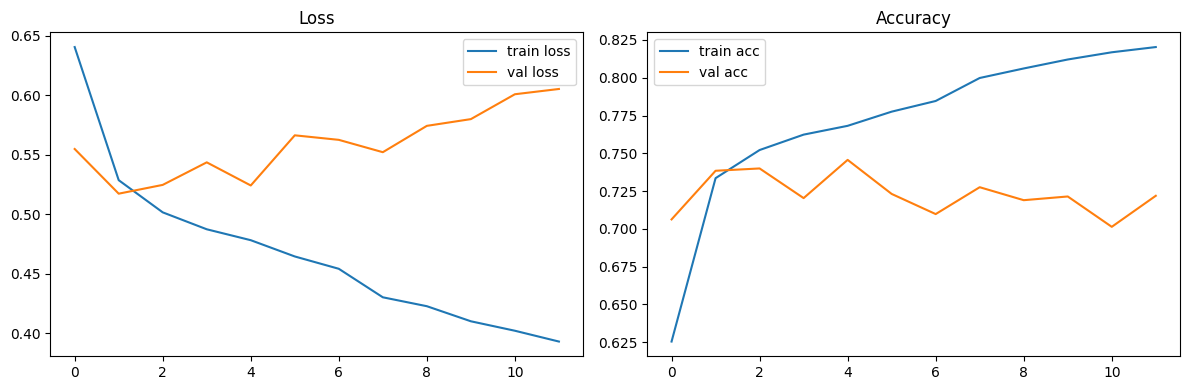

In [63]:
import matplotlib.pyplot as plt 
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['loss'],label='train loss')
axes[0].plot(history.history['val_loss'],label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'],label='train acc')
axes[1].plot(history.history['val_accuracy'],label='val acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()  
plt.show()

In [677]:
test_data=pd.DataFrame()
start_date='2026-01-01T00:00:00'
end_date='2026-04-01T00:00:00'
interval='30min'
api_url=f'https://api.twelvedata.com/{technical}?symbol={ticker}&order=asc&timezone={timezone}&start_date={start_date}&end_date={end_date}&interval={interval}&outputsize=5000&apikey={api_key}'
fetch=requests.get(api_url).json()
df=pd.DataFrame(fetch['values'])
test_data=pd.concat([df,test_data])
test_data.to_csv('BTC_Jan-Mar26.csv')

In [ ]:
df_volume=[]
df_takervolume=[]
df_opentime=[]
df_trades=[]
interval='30m'
session=requests.Session()
retries=Retry(total=5,backoff_factor=1,status_forcelist=[429,500,502,503,504])
session.mount("https://",HTTPAdapter(max_retries=retries))
for yr in range(2026,2027):
    for m in range(1,4): 
        start_date=f'{yr}-{(m):02d}-01'
        end_date=f'{yr}-{(m):02d}-16'
        start_ms=int(time.mktime(time.strptime(start_date,"%Y-%m-%d")))*1000
        end_ms=int(time.mktime(time.strptime(end_date,"%Y-%m-%d")))*1000
        api_url=f"https://api1.binance.com/api/v3/klines?symbol=BTCUSDT&interval={interval}&startTime={start_ms}&endTime={end_ms}&limit=1000"
        while True:
            fetch=session.get(api_url).json()
            if fetch:
                open_time=[value[0] for value in fetch]
                volume=[float(value[7]) for value in fetch]
                taker_volume=[float(value[10]) for value in fetch]
                trades=[float(value[8]) for value in fetch]
                df_volume.extend(volume)
                df_opentime.extend(open_time) 
                df_takervolume.extend(taker_volume)
                df_trades.extend(trades)
                time.sleep(0.1)
                break
            else: 
                print("API Error:",fetch)
                fetch=None
                break
        last_day=calendar.monthrange(yr,m)[1]
        start_date=f'{yr}-{(m):02d}-16'
        end_date=f'{yr}-{(m+1):02d}-01'
        start_ms=int(time.mktime(time.strptime(start_date,"%Y-%m-%d")))*1000
        end_ms=int(time.mktime(time.strptime(end_date,"%Y-%m-%d")))*1000
        api_url=f"https://api1.binance.com/api/v3/klines?symbol=BTCUSDT&interval={interval}&startTime={start_ms}&endTime={end_ms}&limit=1000"
        while True:
            fetch=session.get(api_url).json()
            if fetch:
                open_time=[value[0] for value in fetch]
                volume=[float(value[7]) for value in fetch]
                taker_volume=[float(value[10]) for value in fetch]
                trades=[float(value[8]) for value in fetch]
                df_volume.extend(volume)
                df_opentime.extend(open_time) 
                df_takervolume.extend(taker_volume)
                df_trades.extend(trades)
                time.sleep(0.1)
                break
            else: 
                print("API Error:",fetch)
                fetch=None
                break
df=pd.DataFrame({
    'open_time':pd.to_datetime(df_opentime,unit='ms'),
    'volume':df_volume,
    'taker_volume':df_takervolume,
    'no_of_trades':df_trades
}).dropna()
df=df.drop_duplicates(subset='open_time').sort_values('open_time').reset_index(drop=True)
df.to_csv('binance_Jan-Mar26.csv')

In [66]:
test_data=pd.read_csv('BTC_Jan-Mar26.csv')
df=pd.read_csv('binance_Jan-Mar26.csv')
df['open_time']=pd.to_datetime(df['open_time'])
df['open_time']=df['open_time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata')
test_data['datetime']=pd.to_datetime(test_data['datetime']).dt.tz_localize('Asia/Kolkata')
test_data=test_data.sort_values('datetime').reset_index(drop=True)
df=df.sort_values('open_time').reset_index(drop=True)
data=pd.merge_asof(test_data,df,left_on='datetime',right_on='open_time',direction='nearest',tolerance=pd.Timedelta('30min'))
data['color']=np.where(data['close']>data['open'],1,0)
data['open']=pd.to_numeric(data['open'])
data['close']=pd.to_numeric(data['close'])
data['body']=abs(data['open']-data['close'])
data['high']=pd.to_numeric(data['high'])
data['low']=pd.to_numeric(data['low'])
future_return=(data['close'].shift(-8)-data['close'])/data['close']
data['label']=np.where(future_return>0.0005,1,np.where(future_return<-0.0005,0,np.nan)) 
data['upper_wick']=np.where(data['color']==1,data['high']-data['close'],data['high']-data['open'])
data['lower_wick']=np.where(data['color']==1,data['open']-data['low'],data['close']-data['low'])
data['body_to_range']=data['body']/(data['high']-data['low']+1e-10)
data['upper_wick_ratio']=data['upper_wick']/(data['high']-data['low']+1e-10)
data['lower_wick_ratio']=data['lower_wick']/(data['high']-data['low']+1e-10)
data['price_change']=data['close'].pct_change()
data['price_change_2']=data['close'].pct_change(2)
data['price_change_4']=data['close'].pct_change(4)
data['price_change_8']=data['close'].pct_change(8)
# data['price_change_12']=data['close'].pct_change(12)
data['price_change_16']=data['close'].pct_change(16)
data['price_change_20']=data['close'].pct_change(20)
data['sma_5']=data['close'].rolling(5).mean()
data['sma_10']=data['close'].rolling(10).mean()
data['sma_20']=data['close'].rolling(20).mean()
data['close_to_sma5']=(data['close']-data['sma_5'])/data['sma_5']
data['close_to_sma10']=(data['close']-data['sma_10'])/data['sma_10']
data['volatility']=data['close'].rolling(10).std()
data['volume']=pd.to_numeric(data['volume'])
data['taker_volume']=pd.to_numeric(data['taker_volume'])
data['no_of_trades']=pd.to_numeric(data['no_of_trades'])
data['taker_buy_ratio']=data['taker_volume']/data['volume']
data['avg_trade_size']=data['volume']/data['no_of_trades']
data['vol_z']=(data['volume']-data['volume'].rolling(48).mean())/data['volume'].rolling(48).std()
data['volume_change']=data['volume'].pct_change()
data['volume_ma']=data['volume'].rolling(window=24).mean()
data['volume_ratio_to_ma']=data['volume']/data['volume_ma']
# delta=data['close'].diff()
# gain=(delta.where(delta>0,0)).rolling(14).mean()
# loss=(-delta.where(delta<0,0)).rolling(14).mean()
# rs=gain/(loss+1e-10)
# data['rsi']=100-(100/(1+rs))
data=data.dropna()
data=data.reset_index(drop=True)
data[feature_cols]=scaler.transform(data[feature_cols])
X=[]
y=[]
for i in range(32,len(data)-32):
    seq=data[i-32:i][feature_cols].values
    label=data.iloc[i]['label']
    X.append(seq)
    y.append(label)
X=np.array(X)
y=np.array(y)
model.evaluate(X,y,verbose=0)

[1.015648365020752, 0.4914054572582245]

In [67]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report
y_pred_proba=model.predict(X,verbose=0)
y_pred=(y_pred_proba>0.5).astype(int).flatten()
accuracy=accuracy_score(y,y_pred)
precision=precision_score(y,y_pred,zero_division=0)
recall=recall_score(y,y_pred,zero_division=0)
f1=2*(precision*recall)/(precision+recall+1e-10)
cm=confusion_matrix(y,y_pred)
print(accuracy,precision,recall,f1,cm)
print(classification_report(y,y_pred))

0.4914054600606673 0.47581441263573543 0.5036572622779519 0.489340101472883 [[ 980 1062]
 [ 950  964]]
              precision    recall  f1-score   support

         0.0       0.51      0.48      0.49      2042
         1.0       0.48      0.50      0.49      1914

    accuracy                           0.49      3956
   macro avg       0.49      0.49      0.49      3956
weighted avg       0.49      0.49      0.49      3956



In [20]:
confidence_bins=[(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),(0.4,0.45),(0.45,0.5),(0.5,0.55),(0.55,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9),(0.9,1.0)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(y_pred_proba>=low)&(y_pred_proba<high)  
    if mask.sum()>0: 
        conf_accuracy=accuracy_score(y[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.30-0.40: 1.0000 (2 predictions)
0.40-0.45: 0.4851 (437 predictions)
0.45-0.50: 0.4997 (1717 predictions)
0.50-0.55: 0.4909 (1369 predictions)
0.55-0.60: 0.4553 (683 predictions)
0.60-0.70: 1.0000 (1 predictions)


In [21]:
confidence_bins=[(0.45,0.47),(0.47,0.49),(0.49,0.5),(0.5,0.51),(0.51,0.53),(0.53,0.55),(0.55,0.57),(0.57,0.6)]
print('Accuracy by Confidence Level:')
for low,high in confidence_bins:
    mask=(y_pred_proba>=low)&(y_pred_proba<high)  
    if mask.sum()>0: 
        conf_accuracy=accuracy_score(y[mask.flatten()],y_pred[mask.flatten()])
        print(f'{low:.2f}-{high:.2f}: {conf_accuracy:.4f} ({mask.sum()} predictions)')

Accuracy by Confidence Level:
0.45-0.47: 0.4580 (607 predictions)
0.47-0.49: 0.5165 (759 predictions)
0.49-0.50: 0.5356 (351 predictions)
0.50-0.51: 0.4574 (317 predictions)
0.51-0.53: 0.4955 (561 predictions)
0.53-0.55: 0.5071 (491 predictions)
0.55-0.57: 0.4830 (470 predictions)
0.57-0.60: 0.3944 (213 predictions)


In [ ]:
print(confusion_matrix(y,y_pred))

In [ ]:
model.save("models/rnn_model_30min.keras")

In [ ]:
import joblib
joblib.dump(scaler,"scalers_30min/scaler.pkl")

In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install tensorflow[and-cuda]

INFO: pip is looking at multiple versions of tensorflow[and-cuda] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow[and-cuda] to determine which version is compatible with other requirements. This could take a while.

The conflict is caused by:
    tensorflow[and-cuda] 2.16.0rc0 depends on nvidia-nccl-cu12==2.19.3; extra == "and-cuda"
    tensorflow[and-cuda] 2.21.0 depends on nvidia-nccl-cu12<3.0 and >=2.27.7; extra == "and-cuda"
    tensorflow[and-cuda] 2.20.0 depends on nvidia-nccl-cu12<3.0 and >=2.25.1; extra == "and-cuda"
    tensorflow[and-cuda] 2.19.1 depends on nvidia-nccl-cu12==2.23.4; extra == "and-cuda"
    tensorflow[and-cuda] 2.19.0 depends on nvidia-nccl-cu12==2.23.4; extra == "and-cuda"
    tensorflow[and-cuda] 2.18.1 depends on nvidia-nccl-cu12==2.21.5; extra == "and-cuda"
    tensorflow[and-cuda] 2.18.0 depends on nvidia-nccl-cu12==2.21.5; extra == "and-cuda"
    tens

ERROR: Cannot install tensorflow[and-cuda]==2.16.0rc0, tensorflow[and-cuda]==2.16.1, tensorflow[and-cuda]==2.16.2, tensorflow[and-cuda]==2.17.0, tensorflow[and-cuda]==2.17.1, tensorflow[and-cuda]==2.18.0, tensorflow[and-cuda]==2.18.1, tensorflow[and-cuda]==2.19.0, tensorflow[and-cuda]==2.19.1, tensorflow[and-cuda]==2.20.0 and tensorflow[and-cuda]==2.21.0 because these package versions have conflicting dependencies.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [1]:
import torch
print(torch.cuda.is_available())

False


In [3]:
device=torch.device("cuda")